# Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
import matplotlib as mpl

# Global settings for publication-quality plots
mpl.rcParams.update({
    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "stix",
    "font.size": 9,          # Base font size
    "axes.titlesize": 10,    # Title font size
    "axes.labelsize": 9,     # X/Y label font size
    "xtick.labelsize": 8,    # Tick label font size
    "ytick.labelsize": 8,
    "legend.fontsize": 8,    # Legend font size

    # Line styles
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Figure
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "figure.figsize": (3.3, 2.5),  # ~1-column figure in most journals
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})


# Checking umbrella coverage

In [3]:
trajs = []
for d in os.listdir('.'):
    if d.endswith('.dat'):
        data = np.loadtxt(d)
        trajs.append(data[:,1])

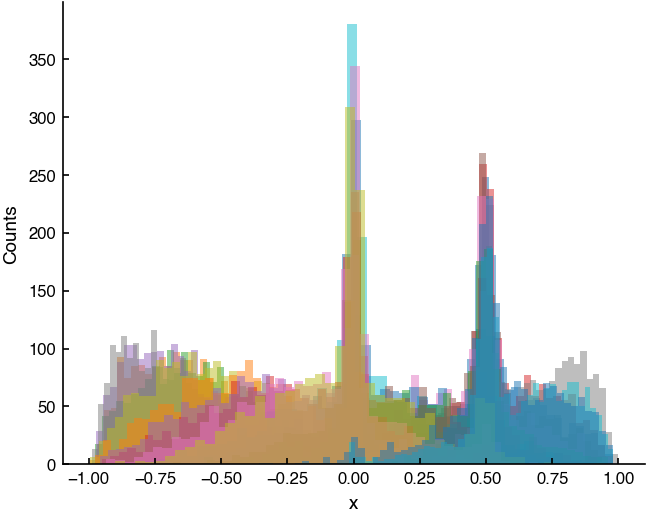

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=150)
for traj in trajs:
    ax.hist(traj, bins=50, alpha=0.5)
    ax.set_xlabel("x")
    ax.set_ylabel("Counts")
plt.show()

# Run WHAM

In [9]:
!python -m pywham.wham1d ../wham1d_config.yaml

# Loading configuration from ../wham1d_config.yaml
# Setting value of k_B to = 1
#Number of windows = 21
#Iteration 10:  0.0029491931090372134
#Iteration 20:  0.0002004639068554901
#Iteration 30:  1.3683690387857777e-05
# Dumping simulation biases, in the metadata file order 
# Window  F (free energy units)
# 0	0.0
# 1	-0.25609934838374904
# 2	-0.45302557496239443
# 3	-0.600358827398498
# 4	-0.7093041448142026
# 5	-0.7916068959757804
# 6	-0.8575874633177801
# 7	-0.9140450989139409
# 8	-0.9634063180119946
# 9	-1.0048738773508379
# 10	-1.0367015092263498
# 11	-1.0577817911359224
# 12	-1.0674182239025336
# 13	-1.063696749122904
# 14	-1.041979595363135
# 15	-0.9948226242182976
# 16	-0.9133024981832271
# 17	-0.7886955673520892
# 18	-0.6135512361723456
# 19	-0.38192988173174286
# 20	-0.08909478332028481
#MC trial 0: 34 iterations
#PMF values
#MC trial 1: 34 iterations
#PMF values
#MC trial 2: 33 iterations
#PMF values
#MC trial 3: 34 iterations
#PMF values
#MC trial 4: 32 iterations
#PMF val

# Load the results

In [10]:
free = np.loadtxt('output.free')

## Reference potential

In [11]:
def potential(x: float) -> float:
    """Test potential used for the sampling."""

    return (
        np.exp(2.5 * x**32)
        - 1.0
        + 0.5 * x**2
        - 2.0 * np.exp(-1000.0 * x**2)
        - 1.75 * np.exp(-500.0 * (x - 0.5) ** 2)
    )

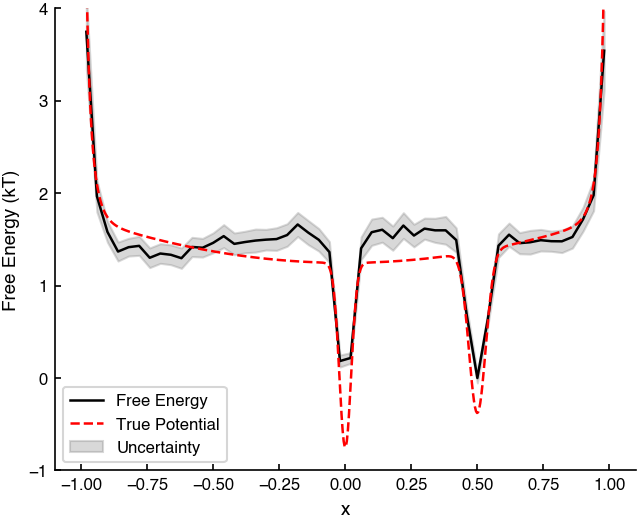

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=150)
ax.plot(free[:,0], free[:,1], label='Free Energy', color='black')
x_vals = np.linspace(-1.0, 1.0, 500)
f_true = potential(x_vals)
ax.plot(x_vals, f_true-f_true.mean()+free[:, 1].mean(), label='True Potential', color='red', linestyle='dashed')
ax.fill_between(free[:,0], free[:,1]-free[:,2], free[:,1]+free[:,2], alpha=0.3, color='gray', label='Uncertainty')
ax.set_ylim(-1, 4)
ax.set_xlabel("x")
ax.set_ylabel("Free Energy (kT)")
ax.legend()
plt.show()